In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 

In [3]:
df=pd.read_csv("loan_approval_data.csv")

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["float64"]).columns


In [6]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [7]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy="mean")
cat_imp=SimpleImputer(strategy="most_frequent")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [8]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

Text(0.5, 1.0, 'is loan approved?')

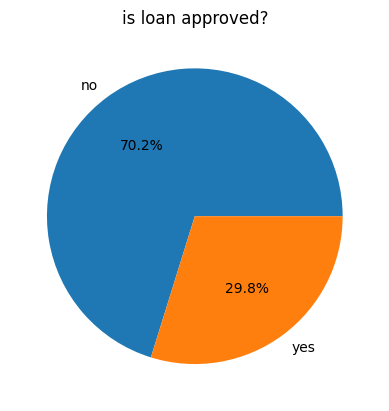

In [9]:
# EDA how balanced the classes are?
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["no","yes"],autopct="%1.1f%%")
plt.title("is loan approved?")

[Text(0, 0, '621'), Text(0, 0, '379')]

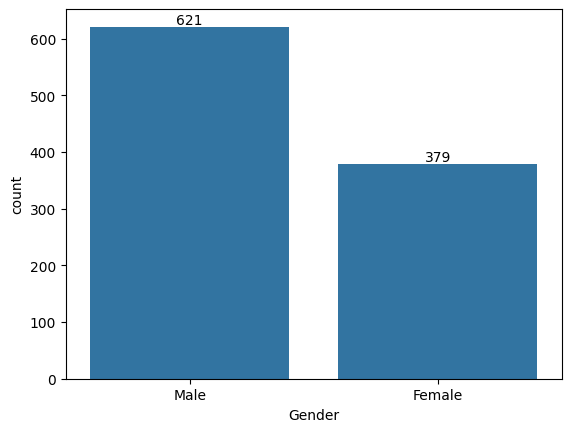

In [10]:
# analyze categories

gender_cat=df["Gender"].value_counts()
ax=sns.barplot(gender_cat)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

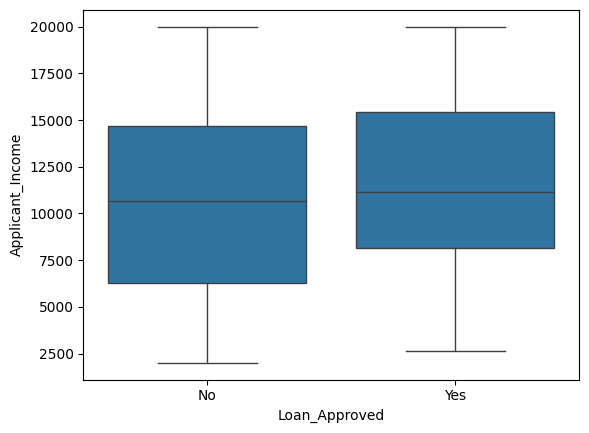

In [11]:
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

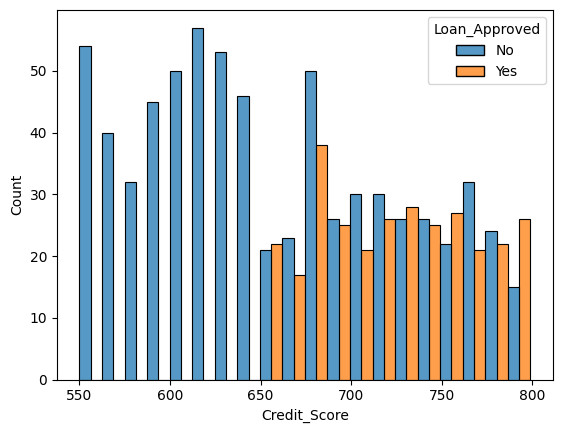

In [12]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    multiple="dodge",
    bins=20
)

In [13]:
# Remove applicant id
df=df.drop(["Applicant_ID"],axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [14]:
# encoding
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le = LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df["Gender"] = le.fit_transform(df["Gender"])

In [15]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,0,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,1,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,0,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,0,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,1,Private,1


In [16]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])

In [17]:
encoded

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(1000, 14))

In [18]:
encode_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

In [19]:
df=pd.concat([df,encode_df],axis=1)

In [20]:
df=df.drop(columns=cols)

In [21]:
x=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) 

In [23]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)                                 

In [24]:
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


In [25]:
print(df.columns.tolist())

['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level', 'Gender', 'Loan_Approved', 'Employment_Status_Salaried', 'Employment_Status_Self-employed', 'Employment_Status_Unemployed', 'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Employer_Category_Government', 'Employer_Category_MNC', 'Employer_Category_Private', 'Employer_Category_Unemployed']


In [26]:
from sklearn.linear_model import LogisticRegression

log_model=LogisticRegression(max_iter=100000)
log_model.fit(x_train_scaled,y_train)

y_pred=log_model.predict(x_test_scaled)

# evaluation

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix   
print("Parameters of Logistic Regression")
print("Accuracy score :",accuracy_score(y_test,y_pred))
print("Precision score :",precision_score(y_test,y_pred))
print("Recall score :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("cm:",confusion_matrix  (y_test,y_pred))

Parameters of Logistic Regression
Accuracy score : 0.865
Precision score : 0.7833333333333333
Recall score : 0.7704918032786885
f1 score : 0.7768595041322314
cm: [[126  13]
 [ 14  47]]


In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn_model= KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)

y_pred=knn_model.predict(x_test_scaled)

# evaluation

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix   
print("Parameters of knn")
print("Accuracy score :",accuracy_score(y_test,y_pred))
print("Precision score :",precision_score(y_test,y_pred))
print("Recall score :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("cm:",confusion_matrix  (y_test,y_pred))

Parameters of knn
Accuracy score : 0.76
Precision score : 0.6274509803921569
Recall score : 0.5245901639344263
f1 score : 0.5714285714285714
cm: [[120  19]
 [ 29  32]]


In [28]:
from sklearn.naive_bayes import GaussianNB

naive_model= GaussianNB()
naive_model.fit(x_train_scaled,y_train)

y_pred=naive_model.predict(x_test_scaled)

# evaluation

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix   
print("Parameters of naive bayes")
print("Accuracy score :",accuracy_score(y_test,y_pred))
print("Precision score :",precision_score(y_test,y_pred))
print("Recall score :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("cm:",confusion_matrix  (y_test,y_pred))

Parameters of naive bayes
Accuracy score : 0.865
Precision score : 0.8035714285714286
Recall score : 0.7377049180327869
f1 score : 0.7692307692307693
cm: [[128  11]
 [ 16  45]]


In [29]:
# Add or Tranform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.7903225806451613
Recall:  0.8032786885245902
F1 score:  0.7967479674796748
Accuracy:  0.875
CM:  [[126  13]
 [ 12  49]]


In [31]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.7833333333333333
Recall:  0.7704918032786885
F1 score:  0.7768595041322314
Accuracy:  0.865
CM:  [[126  13]
 [ 14  47]]
